In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import classification_report

import seaborn as sns

from keras.models import Sequential
from keras.layers import Dense

In [ ]:
df = pd.read_csv('heart.csv')

df_origin = df.copy()

In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [ ]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [ ]:
df.duplicated().sum()

0

In [ ]:
df.shape

(918, 12)

In [ ]:
df['ChestPainType'].value_counts()

ASY    496
NAP    203
ATA    173
TA      46
Name: ChestPainType, dtype: int64

In [ ]:
df['RestingECG'].value_counts()

Normal    552
LVH       188
ST        178
Name: RestingECG, dtype: int64

In [ ]:
df['ExerciseAngina'].value_counts()

N    547
Y    371
Name: ExerciseAngina, dtype: int64

In [ ]:
df['ST_Slope'].value_counts()

Flat    460
Up      395
Down     63
Name: ST_Slope, dtype: int64

In [ ]:
df['Sex'].value_counts()

M    725
F    193
Name: Sex, dtype: int64

In [ ]:
map_CP = {'ASY': 0, 'NAP': 1, 'ATA': 2, 'TA': 3}
df['ChestPainType'] = df['ChestPainType'].map(map_CP)

map_Resting = {'Normal': 0, 'LVH': 1, 'ST': 2}
df['RestingECG'] = df['RestingECG'].map(map_Resting)

map_Angina = {'N': 0, 'Y': 1}
df['ExerciseAngina'] = df['ExerciseAngina'].map(map_Angina)

map_Slope = {'Flat': 0, 'Up': 1, 'Down': 2}
df['ST_Slope'] = df['ST_Slope'].map(map_Slope)

map_Sex = {'M': 0, 'F': 1}
df['Sex'] = df['Sex'].map(map_Sex)

In [ ]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,2,140,289,0,0,172,0,0.0,1,0
1,49,1,1,160,180,0,0,156,0,1.0,0,1
2,37,0,2,130,283,0,2,98,0,0.0,1,0
3,48,1,0,138,214,0,0,108,1,1.5,0,1
4,54,0,1,150,195,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,3,110,264,0,0,132,0,1.2,0,1
914,68,0,0,144,193,1,0,141,0,3.4,0,1
915,57,0,0,130,131,0,0,115,1,1.2,0,1
916,57,1,2,130,236,0,1,174,0,0.0,0,1


In [ ]:
df.describe()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,0.210240,0.748366,132.396514,198.799564,0.233115,0.592593,136.809368,0.404139,0.887364,0.567538,0.553377
std,9.432617,0.407701,0.931031,18.514154,109.384145,0.423046,0.793670,25.460334,0.490992,1.066570,0.618959,0.497414
min,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,0.000000,0.000000,120.000000,173.250000,0.000000,0.000000,120.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,0.000000,0.000000,130.000000,223.000000,0.000000,0.000000,138.000000,0.000000,0.600000,0.000000,1.000000
75%,60.000000,0.000000,1.000000,140.000000,267.000000,0.000000,1.000000,156.000000,1.000000,1.500000,1.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,1.000000


# Analise da Base


In [ ]:
# Age

# Sex

# ChestPainType = Tipo de dor no peito pode ser: TA: Typical Angina - 3, ATA: Atypical Angina - 2, NAP: Non-Anginal Pain = 1, ASY: Asymptomatic - 0

# RestingBP: resting blood pressure [mm Hg]

# Cholesterol: serum cholesterol [mm/dl]

# FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]

# thalach = maximum heart rate achieved

# RestingECG: resting electrocardiogram results [0 - Normal: Normal, 1 - ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV),
# 2 - LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]

# MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]

# ExerciseAngina: exercise-induced angina [1 - Y: Yes, 0 - N: No]

# Oldpeak: oldpeak = ST [Numeric value measured in depression]

# ST_Slope: the slope of the peak exercise ST segment [0 - Flat: flat, 1 - Up: upsloping,  2 - Down: downsloping]

# HeartDisease: output class [1: heart disease, 0: Normal]

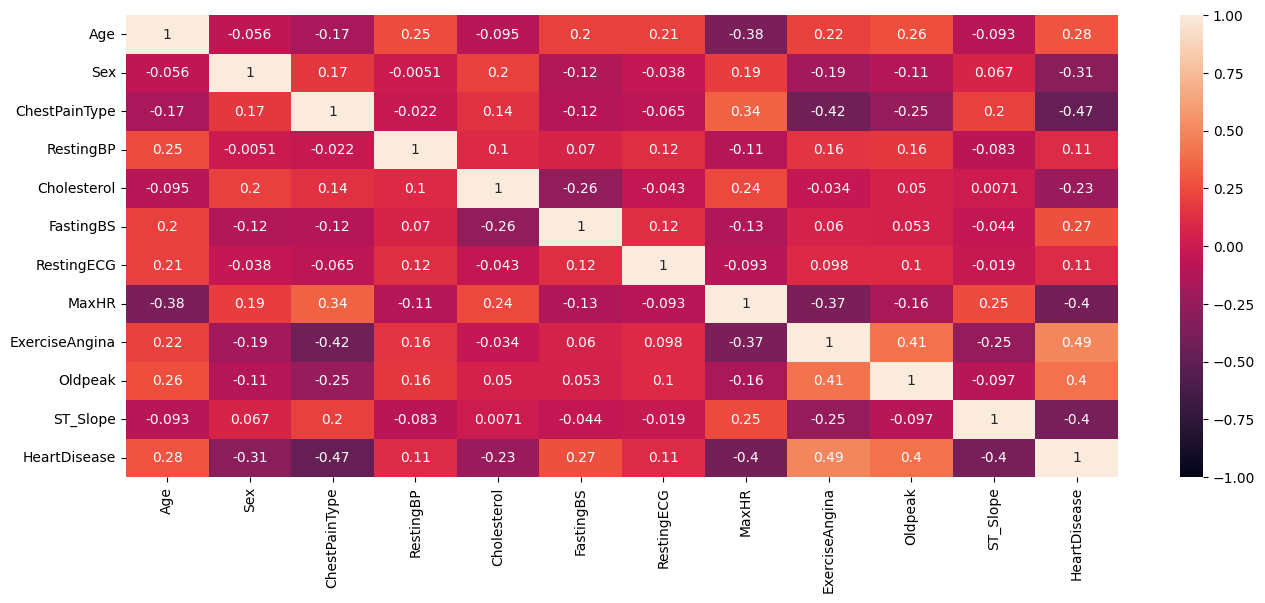

In [ ]:
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(df.corr(), vmin=-1, vmax=1, annot=True)

In [ ]:
# Contando a quantidade de zeros e uns na coluna 'target'
count_target = df['HeartDisease'].value_counts().reset_index()
count_target.columns = ['HeartDisease', 'count']

# Criando o gráfico de barras com Plotly Express
fig = px.bar(count_target, x='HeartDisease', y='count', color='HeartDisease',
             labels={'HeartDisease': 'Valor do Alvo', 'count': 'Quantidade'},
             title='Quantidade de Zeros e Uns na Coluna HeartDisease')
fig.show()

In [ ]:
count_oldpeak = df['Oldpeak'].value_counts().reset_index()
count_oldpeak.columns = ['Oldpeak', 'count']

fig = px.bar(count_oldpeak, x='Oldpeak', y='count', color='count',
             labels={'Oldpeak': 'Valor do Alvo', 'count': 'Quantidade'},
             title='oldpeak')
fig.show()

In [ ]:
# Criando o gráfico de caixa com Plotly Express
fig_box = px.box(df, x='HeartDisease', y='Oldpeak', points="all",
                 labels={'Oldpeak': 'Oldpeak', 'HeartDisease': 'HeartDisease'},
                 title='Distribuição de Oldpeak por HeartDisease (Box Plot)')
fig_box.show()

In [ ]:
count_Angina = df['ExerciseAngina'].value_counts().reset_index()
count_Angina.columns = ['ExerciseAngina', 'count']

fig = px.bar(count_Angina, x='ExerciseAngina', y='count', color='ExerciseAngina',
             labels={'ExerciseAngina': 'Valor do Alvo', 'count': 'Quantidade'},
             title='ExerciseAngina')
fig.show()

In [ ]:
grouped_data = df.groupby(['HeartDisease', 'ExerciseAngina']).size().reset_index(name='count')

# Criando o gráfico de barras empilhadas com Plotly Express
fig = px.bar(grouped_data, x='HeartDisease', y='count', color='ExerciseAngina',
             labels={'count': 'Count', 'HeartDisease': 'Heart Disease', 'ExerciseAngina': 'Exercise Angina'},
             title='Relação entre Heart Disease e Exercise Angina',
             barmode='stack')
fig.show()

In [ ]:
count_Age = df['Age'].value_counts().reset_index()
count_Age.columns = ['Age', 'count']

fig = px.bar(count_Age, x='Age', y='count', color='count',
             labels={'Age': 'Valor do Alvo', 'count': 'Quantidade'},
             title='Age')
fig.show()

In [ ]:
fig_box = px.box(df, x='HeartDisease', y='Age', points="all",
                 labels={'Age': 'Age', 'HeartDisease': 'HeartDisease'},
                 title='Distribuição de Age por HeartDisease (Box Plot)')
fig_box.show()

# Random Forest

In [ ]:
rdf = RandomForestClassifier(max_depth=40, random_state=10)

In [ ]:
df.iloc[:, :10]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak
0,40,0,2,140,289,0,0,172,0,0.0
1,49,1,1,160,180,0,0,156,0,1.0
2,37,0,2,130,283,0,2,98,0,0.0
3,48,1,0,138,214,0,0,108,1,1.5
4,54,0,1,150,195,0,0,122,0,0.0
...,...,...,...,...,...,...,...,...,...,...
913,45,0,3,110,264,0,0,132,0,1.2
914,68,0,0,144,193,1,0,141,0,3.4
915,57,0,0,130,131,0,0,115,1,1.2
916,57,1,2,130,236,0,1,174,0,0.0


In [ ]:
df.iloc[:, 11]

0      0
1      1
2      0
3      1
4      0
      ..
913    1
914    1
915    1
916    1
917    0
Name: HeartDisease, Length: 918, dtype: int64

In [ ]:
data = df.iloc[:, :10]
classe = df.iloc[:, 11]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(data, classe, test_size=0.2, random_state=42)

In [ ]:
rdf.fit(x_train, y_train)

RandomForestClassifier(max_depth=40, random_state=10)

In [ ]:
predicted = rdf.predict(x_test)

In [ ]:
target_names = [ 'class 0 - Normal', 'class 1 - heart disease']
print(classification_report(y_test, predicted, target_names=target_names))

                         precision    recall  f1-score   support

       class 0 - Normal       0.70      0.81      0.75        77
class 1 - heart disease       0.84      0.76      0.80       107

               accuracy                           0.78       184
              macro avg       0.77      0.78      0.77       184
           weighted avg       0.79      0.78      0.78       184


In [ ]:
# Calculando a curva ROC
fpr, tpr, thresholds = roc_curve(y_test, predicted)
roc_auc = roc_auc_score(y_test, predicted)

In [ ]:
# Criando o gráfico ROC com Plotly
fig = go.Figure()

fig.add_trace(go.Scatter(x=fpr, y=tpr,
                    mode='lines',
                    name='ROC curve (area = %0.2f)' % roc_auc))

fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], line=dict(dash='dash'),
                    mode='lines', name='Random'))

fig.update_layout(title='Receiver Operating Characteristic (ROC)',
                  xaxis_title='False Positive Rate',
                  yaxis_title='True Positive Rate',
                  legend=dict(x=0, y=1, bordercolor='black', borderwidth=1))

fig.show()

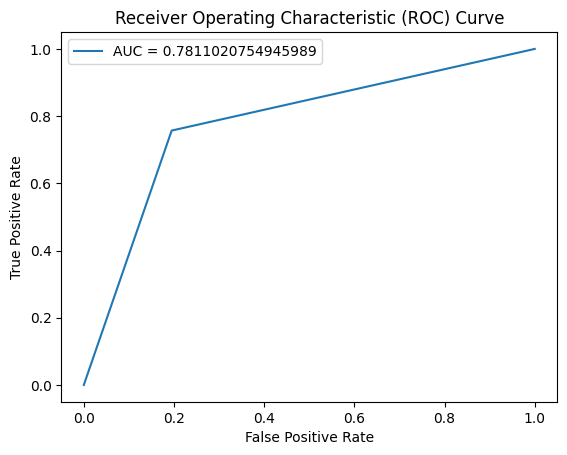

In [ ]:
plt.plot(fpr, tpr, label=f'AUC = {roc_auc}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [ ]:
cm = confusion_matrix(y_test, predicted)
#(classe, predicted2)

In [ ]:
# Definindo os rótulos das classes
class_names = ['Normal', 'Heart Disease']

# Criando a matriz de confusão com Plotly
fig = ff.create_annotated_heatmap(z=cm, x=class_names, y=class_names,
                                   colorscale='Viridis', showscale=True)

# Adicionando informações extras à figura
fig.update_layout(title='Matriz de Confusão',
                  xaxis_title='Valor Previsto',
                  yaxis_title='Valor Verdadeiro',
                  font=dict(family="Arial, sans-serif"),
                  )

# Mostrando a figura
fig.show()

# Rede Densa

In [ ]:
data = df.iloc[:, :10]
classe = df.iloc[:, 11]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(data, classe, test_size=0.3)

In [ ]:
previsor = Sequential()

previsor.add(Dense(units=10, input_dim=10, activation='sigmoid'))

previsor.add(Dense(units=64, activation='sigmoid'))
previsor.add(Dense(units=128, activation='sigmoid'))
previsor.add(Dense(units=256, activation='sigmoid'))

previsor.add(Dense(units=1, activation='sigmoid'))

previsor.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])

In [ ]:
previsor.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 10)                110       
                                                                 
 dense_1 (Dense)             (None, 64)                704       
                                                                 
 dense_2 (Dense)             (None, 128)               8320      
                                                                 
 dense_3 (Dense)             (None, 256)               33024     
                                                                 
 dense_4 (Dense)             (None, 1)                 257       
                                                                 
Total params: 42415 (165.68 KB)
Trainable params: 42415 (165.68 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
previsor.fit(x_train, y_train, batch_size=10, epochs=200, validation_data=(x_test, y_test))

Epoch 1/200
65/65 [==============================] - 0s 4ms/step - loss: 0.6131 - binary_accuracy: 0.6464 - val_loss: 0.6131 - val_binary_accuracy: 0.6848
Epoch 2/200
65/65 [==============================] - 0s 4ms/step - loss: 0.6106 - binary_accuracy: 0.6402 - val_loss: 0.6182 - val_binary_accuracy: 0.6703
Epoch 3/200
65/65 [==============================] - 0s 3ms/step - loss: 0.6117 - binary_accuracy: 0.6153 - val_loss: 0.6188 - val_binary_accuracy: 0.6957
Epoch 4/200
65/65 [==============================] - 0s 4ms/step - loss: 0.6175 - binary_accuracy: 0.6308 - val_loss: 0.6166 - val_binary_accuracy: 0.6920
Epoch 5/200
65/65 [==============================] - 0s 4ms/step - loss: 0.6153 - binary_accuracy: 0.6402 - val_loss: 0.6107 - val_binary_accuracy: 0.6775
Epoch 6/200
65/65 [==============================] - 0s 3ms/step - loss: 0.6116 - binary_accuracy: 0.6355 - val_loss: 0.6260 - val_binary_accuracy: 0.5435
Epoch 7/200
65/65 [==============================] - 0s 3ms/step - los

In [ ]:
predicted = previsor.predict(x_test)

9/9 [==============================] - 0s 2ms/step


In [ ]:
# Defina um limite para converter as probabilidades em previsões binárias
limiar = 0.5  # Por exemplo, se a probabilidade for maior que 0.5, será atribuído como 1, caso contrário, 0

# Converte as probabilidades em previsões binárias
y_pred = [1 if prob >= limiar else 0 for prob in predicted]

In [ ]:
target_names = [ 'class 0 - Normal', 'class 1 - heart disease']
print(classification_report(y_test, predicted, target_names=target_names))

In [ ]:
target_names = [ 'class 0 - Normal', 'class 1 - heart disease']
print(classification_report(y_test, y_pred, target_names=target_names))

                         precision    recall  f1-score   support

       class 0 - Normal       0.85      0.80      0.82       126
class 1 - heart disease       0.84      0.88      0.86       150

               accuracy                           0.84       276
              macro avg       0.84      0.84      0.84       276
           weighted avg       0.84      0.84      0.84       276


In [ ]:
# Calculando a curva ROC
fpr, tpr, thresholds = roc_curve(y_test, predicted)
roc_auc = roc_auc_score(y_test, predicted)

In [ ]:
# Criando o gráfico ROC com Plotly
fig = go.Figure()

fig.add_trace(go.Scatter(x=fpr, y=tpr,
                    mode='lines',
                    name='ROC curve (area = %0.2f)' % roc_auc))

fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], line=dict(dash='dash'),
                    mode='lines', name='Random'))

fig.update_layout(title='Receiver Operating Characteristic (ROC)',
                  xaxis_title='False Positive Rate',
                  yaxis_title='True Positive Rate',
                  legend=dict(x=0, y=1, bordercolor='black', borderwidth=1))

fig.show()

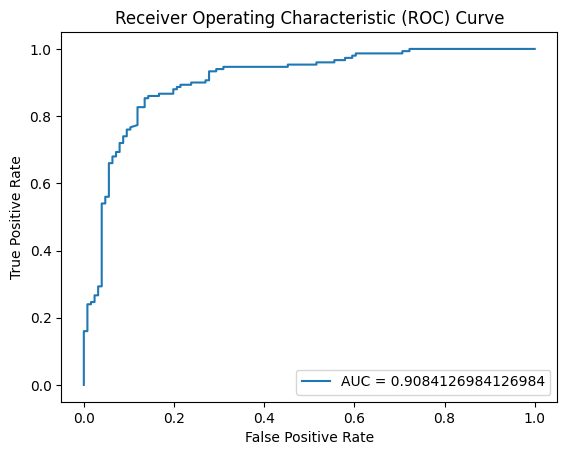

In [ ]:
plt.plot(fpr, tpr, label=f'AUC = {roc_auc}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [ ]:
# Calcula a matriz de confusão para a classe de interesse
cm = confusion_matrix(y_test, y_pred)

In [ ]:
# Definindo os rótulos das classes
class_names = ['Normal', 'Heart Disease']

# Criando a matriz de confusão com Plotly
fig = ff.create_annotated_heatmap(z=cm, x=class_names, y=class_names,
                                   colorscale='Viridis', showscale=True)

# Adicionando informações extras à figura
fig.update_layout(title='Matriz de Confusão',
                  xaxis_title='Valor Previsto',
                  yaxis_title='Valor Verdadeiro',
                  font=dict(family="Arial, sans-serif"),
                  )

# Mostrando a figura
fig.show()